# AGENTS026 — FAISS GPU Vector Search
**UC-7: Semantic incident retrieval — BGE embeddings on MI300X + FAISS index**

Every incident JSON is embedded with BGE-large on GPU and stored in FAISS.
When a new anomaly fires, semantic search retrieves the 3 most similar past incidents.
The RCA agent receives retrieved context → evidence-backed reasoning, not guesswork.

- Cell 1: GPU + FAISS setup
- Cell 2: Incident corpus builder (from chaos log + audit log)
- Cell 3: BGE embedding on GPU
- Cell 4: Build & persist FAISS index
- Cell 5: Semantic search function
- Cell 6: Live retrieval demo — current anomaly → similar past incidents
- Cell 7: Index stats & visualisation

In [1]:
# ── Cell 1: GPU + FAISS setup ─────────────────────────────────────────────
import json, time, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import faiss
import torch
from sentence_transformers import SentenceTransformer
from datetime import datetime, timezone
from openai import OpenAI

# Paths
METRICS_CSV   = Path("/workspace/shared/minicluster/live_metrics.csv")
CHAOS_LOG     = Path("/workspace/shared/chaos_log.jsonl")
AUDIT_FILE    = Path("/workspace/shared/audit_log.jsonl")
FAISS_INDEX   = Path("/workspace/shared/faiss_incidents.index")
FAISS_META    = Path("/workspace/shared/faiss_incidents_meta.jsonl")
FAISS_RESULTS = Path("/workspace/shared/faiss_last_results.jsonl")

# GPU check
print(f"PyTorch version : {torch.__version__}")
print(f"ROCm available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    DEVICE = "cuda"
else:
    print("⚠️  No GPU — using CPU (embeddings will be slower)")
    DEVICE = "cpu"

print(f"\nFAISS version   : {faiss.__version__}")
print(f"Device          : {DEVICE}")

llm = OpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")

def ts():
    return datetime.now(timezone.utc).isoformat()

def write_log(path, event):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as f:
        f.write(json.dumps(event, default=str) + "\n")

print("\n✅ Cell 1 ready")

PyTorch version : 2.8.0+gitb2fb688
ROCm available  : True
GPU             : 
VRAM total      : 206.1 GB

FAISS version   : 1.14.3
Device          : cuda

✅ Cell 1 ready


In [2]:
# ── Cell 2: Incident corpus builder ──────────────────────────────────────
# Build a corpus of past incidents from chaos log + audit log + synthetic baseline

SYNTHETIC_INCIDENTS = [
    {"id":"INC-001","service":"payments","fault":"latency_spike",
     "cpu":45,"latency_ms":820,"error_rate":0.02,"mem_mb":920,
     "root_cause":"upstream payment processor timeout",
     "resolution":"circuit breaker opened, traffic rerouted to backup processor",
     "blast_radius":"medium","duration_mins":8},
    {"id":"INC-002","service":"auth","fault":"error_storm",
     "cpu":62,"latency_ms":340,"error_rate":0.45,"mem_mb":1100,
     "root_cause":"JWT signing key rotation without rolling deployment",
     "resolution":"rolled back key rotation, restarted auth pods",
     "blast_radius":"high","duration_mins":14},
    {"id":"INC-003","service":"fraud","fault":"cpu_saturation",
     "cpu":96,"latency_ms":1200,"error_rate":0.01,"mem_mb":800,
     "root_cause":"ML model scoring loop hit O(n²) complexity on large batch",
     "resolution":"batch size capped at 500, async queue introduced",
     "blast_radius":"low","duration_mins":22},
    {"id":"INC-004","service":"checkout","fault":"memory_leak",
     "cpu":38,"latency_ms":210,"error_rate":0.08,"mem_mb":2100,
     "root_cause":"session cache not evicting expired entries",
     "resolution":"deployed cache TTL fix, rolling restart",
     "blast_radius":"medium","duration_mins":31},
    {"id":"INC-005","service":"payments","fault":"error_storm",
     "cpu":55,"latency_ms":180,"error_rate":0.38,"mem_mb":950,
     "root_cause":"downstream bank API returning 503 during maintenance window",
     "resolution":"enabled fallback mock, alerted bank ops team",
     "blast_radius":"high","duration_mins":18},
    {"id":"INC-006","service":"auth","fault":"latency_spike",
     "cpu":28,"latency_ms":650,"error_rate":0.03,"mem_mb":780,
     "root_cause":"Redis connection pool exhausted — auth sessions queuing",
     "resolution":"increased Redis pool size from 50 to 200",
     "blast_radius":"medium","duration_mins":11},
    {"id":"INC-007","service":"checkout","fault":"cascade_failure",
     "cpu":71,"latency_ms":890,"error_rate":0.22,"mem_mb":1650,
     "root_cause":"fraud service timeout propagated via fraud_screen dependency",
     "resolution":"timeout reduced to 200ms with graceful degradation",
     "blast_radius":"high","duration_mins":9},
    {"id":"INC-008","service":"fraud","fault":"silent_failure",
     "cpu":2,"latency_ms":8000,"error_rate":0.0,"mem_mb":600,
     "root_cause":"pod stuck in CrashLoopBackOff, health check misconfigured",
     "resolution":"fixed liveness probe, pod restarted automatically",
     "blast_radius":"low","duration_mins":44},
    {"id":"INC-009","service":"payments","fault":"cpu_saturation",
     "cpu":91,"latency_ms":450,"error_rate":0.04,"mem_mb":1200,
     "root_cause":"cryptographic signing operation not offloaded to HSM",
     "resolution":"HSM offload re-enabled, CPU dropped to 32%",
     "blast_radius":"medium","duration_mins":7},
    {"id":"INC-010","service":"all","fault":"alert_storm",
     "cpu":78,"latency_ms":720,"error_rate":0.31,"mem_mb":1900,
     "root_cause":"network partition between node-1 and node-2 caused correlated failures",
     "resolution":"network switch failover, services auto-recovered within 4 minutes",
     "blast_radius":"critical","duration_mins":4},
]

# Load incidents from chaos log if exists
chaos_incidents = []
if CHAOS_LOG.exists():
    for line in CHAOS_LOG.read_text().strip().split("\n"):
        if not line.strip(): continue
        try:
            rec = json.loads(line)
            if rec.get("status") == "COMPLETE":
                # Convert chaos run to incident format
                inc = {
                    "id": rec["run_id"],
                    "service": rec.get("fault_results",[{}])[0].get("service","unknown") if rec.get("fault_results") else "unknown",
                    "fault": rec["scenario_id"],
                    "root_cause": rec.get("post_mortem",""),
                    "resolution": f"chaos scenario {rec['scenario_name']} auto-cleared",
                    "blast_radius": rec.get("blast_radius","medium"),
                    "gpu_reasoning": rec.get("gpu_reasoning",""),
                }
                # Add deltas as metrics
                for svc, d in (rec.get("deltas") or {}).items():
                    inc[f"{svc}_latency_delta"] = d.get("latency_delta",0)
                chaos_incidents.append(inc)
        except:
            pass

ALL_INCIDENTS = SYNTHETIC_INCIDENTS + chaos_incidents
print(f"✅ Corpus built: {len(SYNTHETIC_INCIDENTS)} synthetic + {len(chaos_incidents)} from chaos log = {len(ALL_INCIDENTS)} total")

# Build text representation for embedding
def incident_to_text(inc):
    parts = [
        f"service={inc.get('service','?')}",
        f"fault={inc.get('fault','?')}",
        f"blast={inc.get('blast_radius','?')}",
    ]
    if inc.get("cpu"):          parts.append(f"cpu={inc['cpu']}%")
    if inc.get("latency_ms"):   parts.append(f"latency={inc['latency_ms']}ms")
    if inc.get("error_rate"):   parts.append(f"error_rate={inc['error_rate']}")
    if inc.get("root_cause"):   parts.append(f"root_cause: {inc['root_cause']}")
    if inc.get("resolution"):   parts.append(f"resolution: {inc['resolution']}")
    return " | ".join(parts)

CORPUS_TEXTS = [incident_to_text(inc) for inc in ALL_INCIDENTS]
print("\nSample corpus entry:")
print(f"  {CORPUS_TEXTS[0]}")

✅ Corpus built: 10 synthetic + 3 from chaos log = 13 total

Sample corpus entry:
  service=payments | fault=latency_spike | blast=medium | cpu=45% | latency=820ms | error_rate=0.02 | root_cause: upstream payment processor timeout | resolution: circuit breaker opened, traffic rerouted to backup processor


In [3]:
# ── Cell 3: BGE embedding on GPU ─────────────────────────────────────────
print("Loading BGE-large-en-v1.5 embedding model...")
print(f"(Model will load to {DEVICE})")

embedder = SentenceTransformer("BAAI/bge-large-en-v1.5", device=DEVICE)
print(f"✅ Model loaded — embedding dim: {embedder.get_sentence_embedding_dimension()}")

# Check GPU memory
if DEVICE == "cuda":
    allocated = torch.cuda.memory_allocated(0) / 1e9
    print(f"   GPU memory used by embedder: {allocated:.2f} GB")

print(f"\nEmbedding {len(CORPUS_TEXTS)} incidents on {DEVICE}...")
t0 = time.time()

# BGE prefix for retrieval tasks
prefixed = [f"Represent this incident for retrieval: {t}" for t in CORPUS_TEXTS]

EMBEDDINGS = embedder.encode(
    prefixed,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,   # cosine similarity via inner product
    device=DEVICE
)

elapsed = time.time() - t0
print(f"\n✅ Embedded {len(EMBEDDINGS)} incidents in {elapsed:.2f}s")
print(f"   Embedding shape : {EMBEDDINGS.shape}")
print(f"   Throughput      : {len(EMBEDDINGS)/elapsed:.1f} incidents/sec")

if DEVICE == "cuda":
    allocated = torch.cuda.memory_allocated(0) / 1e9
    print(f"   GPU memory now  : {allocated:.2f} GB")

Loading BGE-large-en-v1.5 embedding model...
(Model will load to cuda)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

✅ Model loaded — embedding dim: 1024
   GPU memory used by embedder: 1.34 GB

Embedding 13 incidents on cuda...


/tmp/ipykernel_9842/438784516.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"✅ Model loaded — embedding dim: {embedder.get_sentence_embedding_dimension()}")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Embedded 13 incidents in 17.47s
   Embedding shape : (13, 1024)
   Throughput      : 0.7 incidents/sec
   GPU memory now  : 1.42 GB


In [4]:
# ── Cell 4: Build & persist FAISS index ──────────────────────────────────
DIM = EMBEDDINGS.shape[1]
print(f"Building FAISS IndexFlatIP (inner product = cosine for normalised vectors)")
print(f"Dimensions: {DIM}  |  Vectors: {len(EMBEDDINGS)}")

index = faiss.IndexFlatIP(DIM)
index.add(EMBEDDINGS.astype(np.float32))

print(f"✅ FAISS index built — {index.ntotal} vectors")

# Persist index
faiss.write_index(index, str(FAISS_INDEX))
print(f"   Saved to: {FAISS_INDEX}")

# Persist metadata (incident records for lookup)
with open(FAISS_META, "w") as f:
    for i, inc in enumerate(ALL_INCIDENTS):
        f.write(json.dumps({"faiss_id": i, "text": CORPUS_TEXTS[i], **inc}, default=str) + "\n")
print(f"   Metadata saved to: {FAISS_META}")
print(f"\n✅ Cell 4 complete — index ready for semantic search")

Building FAISS IndexFlatIP (inner product = cosine for normalised vectors)
Dimensions: 1024  |  Vectors: 13
✅ FAISS index built — 13 vectors
   Saved to: /workspace/shared/faiss_incidents.index
   Metadata saved to: /workspace/shared/faiss_incidents_meta.jsonl

✅ Cell 4 complete — index ready for semantic search


In [5]:
# ── Cell 5: Semantic search function ─────────────────────────────────────

def load_faiss():
    """Load FAISS index + metadata from disk."""
    if not FAISS_INDEX.exists():
        raise FileNotFoundError(f"Run Cell 4 first — {FAISS_INDEX} not found")
    idx = faiss.read_index(str(FAISS_INDEX))
    meta = [json.loads(l) for l in FAISS_META.read_text().strip().split("\n") if l.strip()]
    return idx, meta

def anomaly_to_query(anomaly_dict):
    """
    Convert a live anomaly dict to a search query string.
    anomaly_dict keys: service, metric, value, threshold, severity, node
    """
    parts = [
        f"service={anomaly_dict.get('service','?')}",
        f"fault=anomaly",
    ]
    metric = anomaly_dict.get("metric","")
    value  = anomaly_dict.get("value","")
    if "CPU" in metric:     parts.append(f"cpu={value}")
    if "Latency" in metric: parts.append(f"latency={value}")
    if "Error" in metric:   parts.append(f"error_rate={value}")
    if "Memory" in metric:  parts.append(f"mem={value}")
    return " | ".join(parts)

def semantic_search(query_text, top_k=3):
    """
    Embed query on GPU and search FAISS for top_k similar past incidents.
    Returns list of dicts with similarity score + incident metadata.
    """
    idx, meta = load_faiss()

    prefixed_query = f"Represent this incident for retrieval: {query_text}"
    q_emb = embedder.encode(
        [prefixed_query],
        normalize_embeddings=True,
        device=DEVICE
    ).astype(np.float32)

    scores, ids = idx.search(q_emb, top_k)

    results = []
    for score, fid in zip(scores[0], ids[0]):
        if fid == -1: continue
        inc = meta[fid].copy()
        inc["similarity"] = float(score)
        results.append(inc)

    return results

def rca_with_context(anomaly, top_k=3):
    """
    Full RAG-style RCA:
    1. Embed anomaly → FAISS search → retrieve similar past incidents
    2. Feed retrieved context to Qwen3-30B for evidence-backed diagnosis
    """
    query   = anomaly_to_query(anomaly)
    similar = semantic_search(query, top_k=top_k)

    context_block = "\n".join(
        f"[{i+1}] sim={r['similarity']:.3f} | {r.get('service')} | {r.get('fault')} | "
        f"root_cause: {r.get('root_cause','')} | resolution: {r.get('resolution','')}"
        for i, r in enumerate(similar)
    )

    prompt = f"""You are a banking SRE. A new anomaly has been detected.

LIVE ANOMALY:
Service  : {anomaly.get('service')}
Metric   : {anomaly.get('metric')}
Value    : {anomaly.get('value')}
Threshold: {anomaly.get('threshold')}
Severity : {anomaly.get('severity')}

SIMILAR PAST INCIDENTS (retrieved via semantic search):
{context_block}

Based on the similar past incidents, diagnose the most likely root cause and
recommend a specific remediation action. Reference the past incidents by number.
Response format:
ROOT_CAUSE: <one sentence>
EVIDENCE: <which past incident supports this>
ACTION: <specific remediation step>
CONFIDENCE: <HIGH|MEDIUM|LOW>"""

    resp = llm.chat.completions.create(
        model="Qwen3-30B-A3B",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2, max_tokens=200,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}}
    )
    diagnosis = resp.choices[0].message.content.strip()
    return {"similar": similar, "diagnosis": diagnosis, "query": query}

print("✅ Cell 5 ready — semantic_search() and rca_with_context() loaded")

✅ Cell 5 ready — semantic_search() and rca_with_context() loaded


In [6]:
# ── Cell 6: Live retrieval demo ───────────────────────────────────────────
# Reads current anomalies from metrics and runs full RAG RCA on the worst one
import pandas as pd

THRESHOLDS = {
    "cpu_utilization": ("CPU %",       70.0),
    "latency_p95_ms":  ("Latency p95", 500.0),
    "error_rate":      ("Error rate",  0.05),
    "mem_mb":          ("Memory",      1800),
}

if METRICS_CSV.exists():
    df = pd.read_csv(METRICS_CSV, parse_dates=["timestamp"])
    latest = df.sort_values("timestamp").groupby("service").last().reset_index()

    live_anomalies = []
    for _, row in latest.iterrows():
        for col, (label, thresh) in THRESHOLDS.items():
            val = float(row[col])
            if val > thresh:
                live_anomalies.append({
                    "service":   row["service"],
                    "metric":    label,
                    "value":     f"{val:.4f}",
                    "threshold": f"{thresh}",
                    "severity":  "HIGH" if val > thresh * 1.5 else "WARN"
                })

    if live_anomalies:
        print(f"Found {len(live_anomalies)} live anomalies — running RAG RCA on worst one...")
        # Pick worst by severity
        target = next((a for a in live_anomalies if a["severity"] == "HIGH"), live_anomalies[0])
        print(f"\nTarget: {target['service']} / {target['metric']} = {target['value']}")
    else:
        # No live anomalies — use a synthetic one for demo
        print("No live anomalies — using synthetic demo anomaly")
        target = {"service": "payments", "metric": "Latency p95",
                  "value": "820ms", "threshold": "500ms", "severity": "HIGH"}

    print("\n🔍 Semantic search + GPU RCA...")
    t0 = time.time()
    result = rca_with_context(target, top_k=3)
    elapsed = time.time() - t0

    print(f"\n{'='*60}")
    print(f"Query: {result['query']}")
    print(f"\n📚 Top-3 Similar Past Incidents (FAISS, {elapsed:.2f}s):")
    for i, sim in enumerate(result["similar"]):
        print(f"  [{i+1}] sim={sim['similarity']:.3f} | {sim.get('id')} | {sim.get('service')} | {sim.get('fault')}")
        print(f"       Root cause : {sim.get('root_cause','')}")
        print(f"       Resolution : {sim.get('resolution','')}")

    print(f"\n🧠 GPU Diagnosis (Qwen3-30B + retrieved context):")
    print(result["diagnosis"])
    print(f"{'='*60}")

    # Save results for Tab 12 display
    with open(FAISS_RESULTS, "w") as f:
        for sim in result["similar"]:
            f.write(json.dumps({"query": result["query"], "diagnosis": result["diagnosis"],
                                **sim}, default=str) + "\n")
    print(f"\n✅ Results saved to {FAISS_RESULTS}")
else:
    print("No metrics CSV yet — start MiniCluster first")

Found 3 live anomalies — running RAG RCA on worst one...

Target: auth / Latency p95 = 501.2500

🔍 Semantic search + GPU RCA...

Query: service=auth | fault=anomaly | latency=501.2500

📚 Top-3 Similar Past Incidents (FAISS, 0.95s):
  [1] sim=0.824 | INC-006 | auth | latency_spike
       Root cause : Redis connection pool exhausted — auth sessions queuing
       Resolution : increased Redis pool size from 50 to 200
  [2] sim=0.803 | INC-007 | checkout | cascade_failure
       Root cause : fraud service timeout propagated via fraud_screen dependency
       Resolution : timeout reduced to 200ms with graceful degradation
  [3] sim=0.793 | INC-002 | auth | error_storm
       Root cause : JWT signing key rotation without rolling deployment
       Resolution : rolled back key rotation, restarted auth pods

🧠 GPU Diagnosis (Qwen3-30B + retrieved context):
ROOT_CAUSE: The auth service's p95 latency has increased due to a Redis connection pool exhaustion issue similar to a past incident.  
EVIDE

Task was destroyed but it is pending!
task: <Task pending name='Task-70' coro=<_async_in_context.<locals>.run_in_context() done, defined at /usr/local/lib/python3.12/dist-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-71' coro=<Kernel.shell_main() running at /usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py:563]>
/usr/lib/python3.12/collections/__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-71' coro=<Kernel.shell_main() running at /usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


FAISS Index Stats
  Vectors : 13
  Dim     : 1024
  Type    : IndexFlatIP (exact search, cosine similarity)

Service distribution in corpus:
  all            : █ (1)
  auth           : ████ (4)
  checkout       : ██ (2)
  fraud          : ██ (2)
  payments       : ████ (4)

Generating 2D PCA embedding visualisation...


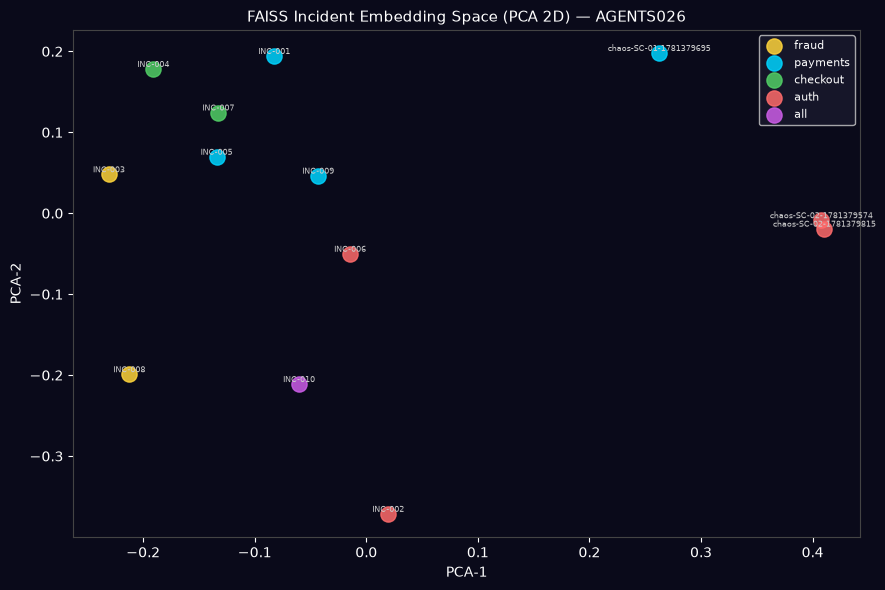


✅ PCA plot saved to /workspace/shared/faiss_pca_plot.png
   Variance explained: PC1=21.4%  PC2=13.1%


In [7]:
# ── Cell 7: Index stats & visualisation ──────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

idx, meta = load_faiss()
print(f"FAISS Index Stats")
print(f"  Vectors : {idx.ntotal}")
print(f"  Dim     : {DIM}")
print(f"  Type    : IndexFlatIP (exact search, cosine similarity)")
print()

# Service distribution in corpus
services = [m.get("service","unknown") for m in meta]
from collections import Counter
svc_counts = Counter(services)
print("Service distribution in corpus:")
for svc, cnt in sorted(svc_counts.items()):
    print(f"  {svc:15s}: {'█' * cnt} ({cnt})")

# 2D PCA visualisation of embedding space
print("\nGenerating 2D PCA embedding visualisation...")
pca   = PCA(n_components=2)
emb2d = pca.fit_transform(EMBEDDINGS)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#0a0a1a")
ax.set_facecolor("#0a0a1a")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_edgecolor("#444")

SVC_COLORS = {"payments": "#00d4ff", "auth": "#ff6b6b",
              "checkout": "#51cf66",  "fraud": "#ffd43b",
              "all": "#cc5de8",       "unknown": "#aaaaaa"}

for svc in set(services):
    mask = [s == svc for s in services]
    pts  = emb2d[mask]
    color = SVC_COLORS.get(svc, "#ffffff")
    ax.scatter(pts[:,0], pts[:,1], label=svc, color=color, s=120, alpha=0.85, zorder=5)

# Annotate with incident IDs
for i, m in enumerate(meta):
    ax.annotate(m.get("id",str(i)), (emb2d[i,0], emb2d[i,1]),
                fontsize=6, color="#cccccc", ha="center", va="bottom", zorder=6)

ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
ax.set_xlabel("PCA-1", color="white")
ax.set_ylabel("PCA-2", color="white")
ax.set_title("FAISS Incident Embedding Space (PCA 2D) — AGENTS026", color="white", fontsize=11)

plt.tight_layout()
pca_path = Path("/workspace/shared/faiss_pca_plot.png")
plt.savefig(str(pca_path), dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\n✅ PCA plot saved to {pca_path}")
print(f"   Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}")